In [1]:
import os
import glob
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix
import pynapple as nap
from spatial_manifolds.toroidal import *
from spatial_manifolds.behaviour_plots import *
from spatial_manifolds.data.binning import get_bin_config
from spatial_manifolds.mlencoding import *
from spatial_manifolds.circular_decoder import circular_decoder, cross_validate_decoder, cross_validate_decoder_time, circular_nanmean
from spatial_manifolds.data.curation import curate_clusters
from scipy.stats import zscore
from spatial_manifolds.util import gaussian_filter_nan
from spatial_manifolds.predictive_grid import compute_travel_projected, wrap_list
from spatial_manifolds.behaviour_plots import *
from spatial_manifolds.detect_grids import *
from spatial_manifolds.brainrender_helper import *
from spatial_manifolds.anaylsis_parameters import ngs_color, gc_color

import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2
%matplotlib inline

fig_path = '/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_5_xgboost_distances/'
source_path = '/Users/harryclark/Downloads/COHORT12/'

cell_classifications = pd.read_csv('/Users/harryclark/Documents/spatial-manifolds/data/cell_classifications.csv')


In [2]:
# ── Analysis configuration ────────────────────────────────────────────────────
# Set to True/False to control which target cell types are computed.
# NGS targets are far more numerous and will take significantly longer to run.
CALCULATE_GC_TARGETS  = True   # predict grid cells (GC)
CALCULATE_NGS_TARGETS = True  # predict non-grid spatial cells (NGS)

# Set to True to skip all computation and only load rows from already-cached files.
# No new models will be fitted; sessions/cells with no cache file are silently skipped.
CACHE_ONLY = False
# ─────────────────────────────────────────────────────────────────────────────


## XGBoost shank assay — GC predicted by NGS cells per shank

### What this analysis does

For every session containing at least one grid cell and at least one non-grid spatial (NGS) cell, we fit XGBoost models to predict each **target grid cell's** firing rate in VR. Two covariate conditions are tested:

| `covariate_type` | Covariates |
|---|---|
| `pos` | Position alone (baseline, fit once per GC) |
| `pos+ngs_shank` | Position + all NGS cells on a given shank (fit once per GC × shank) |

Shank IDs (0–3) are assigned from `probe_x` (electrode x-position on the probe) via `reconstruct_shank_id`. Only shanks that contain at least one NGS cell contribute a `pos+ngs_shank` row for a given GC.

This lets us ask whether NGS activity on a particular shank — including the same shank as the GC — predicts the GC's VR firing above and beyond position alone, enabling shank-by-shank population comparison.

---

### Resulting dataframe — `results_df`

Each row is one XGBoost model fit. Columns:

| Column | Description |
|---|---|
| `mouse` | Mouse ID |
| `day` | Recording day |
| `target_cluster_id` | Cluster ID of the GC being predicted |
| `target_shank_id` | Shank ID of the target GC (0–3) |
| `cov_shank_id` | Shank ID of the NGS covariate pool (`NaN` for baseline) |
| `n_ngs_cells` | Number of NGS cells used as covariates (`NaN` for baseline) |
| `covariate_type` | `pos` or `pos+ngs_shank` |
| `pR2_cv` | Cross-validated Poisson pseudo-R² (mean across CV folds) |
| `mean_dist_to_ngs_um` | Mean 3-D Euclidean distance (µm) from GC to NGS cells on that shank (`NaN` for baseline) |


In [3]:

# XGBoost model parameters
history_length = 1000  # ms
nfilters = int(history_length / time_bs)

xgb_history = MLencoding(
    tunemodel='xgboost',
    cov_history=True,
    spike_history=False,
    window=time_bs,
    n_filters=nfilters,
    max_time=history_length,
)

all_rows = []

cache_dir = '/Users/harryclark/Documents/spatial-manifolds/data/gc_ngs_shank_xgboost_cache'
os.makedirs(cache_dir, exist_ok=True)

# Sessions with at least 1 GC and at least 1 NGS cell
gc_sessions  = cell_classifications[cell_classifications['cell_type'] == 'GC'][['mouse', 'day']].drop_duplicates()
ngs_sessions = cell_classifications[cell_classifications['cell_type'] == 'NG'][['mouse', 'day']].drop_duplicates()
valid_sessions = gc_sessions.merge(ngs_sessions, on=['mouse', 'day'])
print(f"{len(valid_sessions)} sessions have at least 1 GC and 1 NGS cell.")

if CACHE_ONLY:
    # ── Cache-only mode: load every .csv that exists, skip everything else ────
    print("CACHE_ONLY=True — loading cached files only, no new models will be fitted.")
    _types_to_run = ['GC', 'NG']  # load all cached types regardless of flags
    for _, sess_row in valid_sessions.iterrows():
        mouse_id = int(sess_row['mouse'])
        day_id   = int(sess_row['day'])
        _sess_targets = cell_classifications[
            (cell_classifications['mouse'] == mouse_id) &
            (cell_classifications['day']   == day_id) &
            (cell_classifications['cell_type'].isin(_types_to_run))
        ]
        _loaded = 0
        for cid in _sess_targets['cluster_id']:
            cache_file = os.path.join(cache_dir, f'M{mouse_id}_D{day_id:02d}_C{int(cid)}.csv')
            if os.path.exists(cache_file):
                all_rows.extend(pd.read_csv(cache_file).to_dict('records'))
                _loaded += 1
        if _loaded:
            print(f"  M{mouse_id} D{day_id:02d}: loaded {_loaded} cached target(s).")
else:
    # ── Compute mode: fit models, using cache where available ─────────────────
    _types_to_run = (
        (['GC'] if CALCULATE_GC_TARGETS  else []) +
        (['NG'] if CALCULATE_NGS_TARGETS else [])
    )
    if not _types_to_run:
        raise ValueError("Both CALCULATE_GC_TARGETS and CALCULATE_NGS_TARGETS are False — nothing to run.")
    print(f"Running for target types: {_types_to_run}")

    expected_shanks = {0, 1, 2, 3}

    for _, sess_row in valid_sessions.iterrows():
        mouse_id = int(sess_row['mouse'])
        day_id   = int(sess_row['day'])
        print(f"\n=== M{mouse_id} D{day_id:02d} ===")

        # ── Session-level cache check: skip loading if all relevant targets are already cached ──
        _sess_targets_check = cell_classifications[
            (cell_classifications['mouse'] == mouse_id) &
            (cell_classifications['day']   == day_id) &
            (cell_classifications['cell_type'].isin(_types_to_run))
        ]
        _target_cache_files = {
            int(cid): os.path.join(cache_dir, f'M{mouse_id}_D{day_id:02d}_C{int(cid)}.csv')
            for cid in _sess_targets_check['cluster_id']
        }
        if len(_target_cache_files) > 0 and all(os.path.exists(f) for f in _target_cache_files.values()):
            for cid, cache_file in _target_cache_files.items():
                all_rows.extend(pd.read_csv(cache_file).to_dict('records'))
            print("  All targets cached — skipping session load.")
            continue

        # Load VR spike trains and behaviour
        tcs, tcs_time, _, last_ephys_bin, beh, clusters = compute_vr_tcs(
            mouse_id, day_id,
            apply_zscore=False, apply_guassian_filter=False,
            source_path=source_path,
        )

        last_ephys_time_bin = clusters[clusters.index[0]].count(
            bin_size=time_bs, time_units='ms'
        ).index[-1]
        ep = nap.IntervalSet(start=0, end=last_ephys_time_bin, time_units='s')

        dt_in_time  = np.array(
            beh['travel'].bin_average(bin_size=time_bs, time_units='ms', ep=ep)
            - ((beh['trial_number'][0] - 1) * tl)
        )
        pos_in_time = dt_in_time % tl
        if np.any(np.isnan(pos_in_time)):
            pos_in_time = pd.Series(dt_in_time).ffill().bfill().values % tl

        # ── Session cell tables ────────────────────────────────────────────────────
        sess_gcs = cell_classifications[
            (cell_classifications['mouse'] == mouse_id) &
            (cell_classifications['day']   == day_id) &
            (cell_classifications['cell_type'] == 'GC')
        ].copy()
        sess_ngs = cell_classifications[
            (cell_classifications['mouse'] == mouse_id) &
            (cell_classifications['day']   == day_id) &
            (cell_classifications['cell_type'] == 'NG')
        ].copy()

        sess_gcs['cluster_id'] = sess_gcs['cluster_id'].astype(int)
        sess_ngs['cluster_id'] = sess_ngs['cluster_id'].astype(int)

        # ── Assign shank IDs from probe_x ─────────────────────────────────────────
        sess_gcs = reconstruct_shank_id(sess_gcs, mouse_id, colname='probe_x')
        sess_ngs = reconstruct_shank_id(sess_ngs, mouse_id, colname='probe_x')

        # Group NGS cells by shank — keep only shanks present in tcs_time
        ngs_by_shank = {
            shank: grp['cluster_id'].values.astype(int)
            for shank, grp in sess_ngs.groupby('shank_id')
            if any(c in tcs_time for c in grp['cluster_id'].astype(int))
        }

        # Require NGS cells on every shank
        if set(ngs_by_shank.keys()) != expected_shanks:
            print(f"  NGS cells not on all shanks (present: {sorted(ngs_by_shank.keys())}) — skipping.")
            continue

        print(f"  GCs: {len(sess_gcs)}  NGS: {len(sess_ngs)}  |  NGS shanks: { {s: len(v) for s,v in ngs_by_shank.items()} }")

        # ── Loop over target cells filtered by the config flags ───────────────────
        sess_targets = pd.concat([sess_gcs, sess_ngs], ignore_index=True)
        sess_targets = sess_targets[sess_targets['cell_type'].isin(_types_to_run)]

        for _, target_row in sess_targets.iterrows():
            target_id    = int(target_row['cluster_id'])
            target_shank = int(target_row['shank_id'])
            target_type  = str(target_row['cell_type'])

            # ── Target-level cache check ───────────────────────────────────────────
            cache_file = os.path.join(cache_dir, f'M{mouse_id}_D{day_id:02d}_C{target_id}.csv')
            if os.path.exists(cache_file):
                print(f"    {target_type} {target_id} (shank {target_shank}): loading from cache.")
                all_rows.extend(pd.read_csv(cache_file).to_dict('records'))
                continue

            if target_id not in tcs_time:
                continue

            y = np.array(tcs_time[target_id])
            T = len(y)
            pos = pos_in_time[:T]
            if len(pos) < T:
                pos = np.pad(pos, (0, T - len(pos)), mode='edge')

            tgt_x = float(target_row['SC_x'])
            tgt_y = float(target_row['SC_y'])
            tgt_z = float(target_row['SC_z'])

            target_rows = []

            # ── Baseline: position only ────────────────────────────────────────────
            _, pR2_cv = xgb_history.fit_cv(pos[:, None], y, verbose=0, continuous_folds=True)
            target_rows.append(dict(
                mouse=mouse_id, day=day_id,
                target_cluster_id=target_id,
                target_shank_id=target_shank,
                target_cell_type=target_type,
                cell_type=target_type,
                cov_shank_id=np.nan,
                n_ngs_cells=np.nan,
                covariate_type='pos',
                pR2_cv=float(np.nanmean(pR2_cv)),
                mean_dist_to_ngs_um=np.nan,
            ))

            # ── One model per NGS shank ────────────────────────────────────────────
            for cov_shank, ngs_cids in ngs_by_shank.items():

                # Keep only NGS cells present in tcs_time, excluding the target itself
                valid_ngs = [c for c in ngs_cids if c in tcs_time and c != target_id]
                if not valid_ngs:
                    continue

                # Stack NGS spike trains
                ngs_mat = np.vstack([
                    np.pad(
                        np.array(tcs_time[c])[:T],
                        (0, max(0, T - len(np.array(tcs_time[c])[:T]))),
                        mode='constant'
                    )
                    for c in valid_ngs
                ]).T  # shape (T, n_ngs)

                x = np.column_stack([pos, ngs_mat])

                # Mean Euclidean distance from target to each NGS cell on this shank
                ngs_coords = sess_ngs[sess_ngs['cluster_id'].isin(valid_ngs)][['SC_x', 'SC_y', 'SC_z']]
                dists = np.sqrt(
                    (ngs_coords['SC_x'].values.astype(float) - tgt_x)**2 +
                    (ngs_coords['SC_y'].values.astype(float) - tgt_y)**2 +
                    (ngs_coords['SC_z'].values.astype(float) - tgt_z)**2
                )
                mean_dist = float(np.nanmean(dists))

                _, pR2_cv = xgb_history.fit_cv(x, y, verbose=0, continuous_folds=True)
                target_rows.append(dict(
                    mouse=mouse_id, day=day_id,
                    target_cluster_id=target_id,
                    target_shank_id=target_shank,
                    target_cell_type=target_type,
                    cell_type=target_type,
                    cov_shank_id=int(cov_shank),
                    n_ngs_cells=len(valid_ngs),
                    covariate_type='pos+ngs_shank',
                    pR2_cv=float(np.nanmean(pR2_cv)),
                    mean_dist_to_ngs_um=mean_dist,
                ))

            # ── Save this target's rows to cache ──────────────────────────────────
            pd.DataFrame(target_rows).to_csv(cache_file, index=False)
            all_rows.extend(target_rows)
            print(f"    {target_type} {target_id} (shank {target_shank}): done.")

results_df = pd.DataFrame(all_rows)

# ── Backfill cell_type / target_cell_type from cell_classifications ────────
# Cache files saved before these columns were added won't have them.
_needs_backfill = (
    'cell_type' not in results_df.columns or results_df['cell_type'].isna().any() or
    'target_cell_type' not in results_df.columns or results_df['target_cell_type'].isna().any()
)
if _needs_backfill and len(results_df) > 0:
    _ct_lookup = (
        cell_classifications[['mouse', 'day', 'cluster_id', 'cell_type']]
        .rename(columns={'cluster_id': 'target_cluster_id'})
        .drop_duplicates(subset=['mouse', 'day', 'target_cluster_id'])
    )
    for _col in ['cell_type', 'target_cell_type']:
        if _col in results_df.columns:
            results_df = results_df.drop(columns=[_col])
    results_df = results_df.merge(_ct_lookup, on=['mouse', 'day', 'target_cluster_id'], how='left')
    results_df['target_cell_type'] = results_df['cell_type']
    print(f"Backfilled cell_type from cell_classifications: {results_df['cell_type'].value_counts().to_dict()}")

print(f"\nTotal rows collected: {len(results_df)}")
print(f"covariate_type counts:\n{results_df['covariate_type'].value_counts()}")
if 'cell_type' in results_df.columns:
    print(f"cell_type counts:\n{results_df['cell_type'].value_counts()}")
results_df.head(10)


66 sessions have at least 1 GC and 1 NGS cell.
Running for target types: ['GC', 'NG']

=== M20 D14 ===
  All targets cached — skipping session load.

=== M20 D15 ===
  All targets cached — skipping session load.

=== M20 D16 ===
  All targets cached — skipping session load.

=== M20 D17 ===
  NGS cells not on all shanks (present: [1, 2, 3]) — skipping.

=== M20 D18 ===
  All targets cached — skipping session load.

=== M20 D19 ===
  All targets cached — skipping session load.

=== M20 D20 ===
  NGS cells not on all shanks (present: [1]) — skipping.

=== M20 D21 ===
  NGS cells not on all shanks (present: [2]) — skipping.

=== M20 D23 ===
  NGS cells not on all shanks (present: [1]) — skipping.

=== M20 D24 ===
  NGS cells not on all shanks (present: [2]) — skipping.

=== M20 D25 ===
  NGS cells not on all shanks (present: [0]) — skipping.

=== M20 D26 ===
  NGS cells not on all shanks (present: [3]) — skipping.

=== M21 D15 ===
M21 unique probe_x values (before remap): [np.float64(0.0)

,mouse,day,target_cluster_id,target_shank_id,cov_shank_id,n_ngs_cells,covariate_type,pR2_cv,mean_dist_to_ngs_um,cell_type,target_cell_type
0,20,14,34,0,NaN,NaN,pos,0.027396,NaN,GC,GC
1,20,14,34,0,0.0,2.0,pos+ngs_shank,0.017168,105.000000,GC,GC
2,20,14,34,0,1.0,32.0,pos+ngs_shank,0.058554,272.320581,GC,GC
3,20,14,34,0,2.0,54.0,pos+ngs_shank,0.055879,410.645610,GC,GC
4,20,14,34,0,3.0,21.0,pos+ngs_shank,0.012833,548.142981,GC,GC
5,20,14,103,1,NaN,NaN,pos,0.016471,NaN,GC,GC
6,20,14,103,1,0.0,2.0,pos+ngs_shank,0.016918,393.745462,GC,GC
7,20,14,103,1,1.0,32.0,pos+ngs_shank,0.069928,207.187500,GC,GC
8,20,14,103,1,2.0,54.0,pos+ngs_shank,0.065179,326.102353,GC,GC
9,20,14,103,1,3.0,21.0,pos+ngs_shank,0.022341,401.951774,GC,GC


In [4]:
save_path = '/Users/harryclark/Documents/spatial-manifolds/data/gc_ngs_shank_xgboost.csv'
results_df.to_csv(save_path, index=False)
print(f"Saved {len(results_df)} rows → {save_path}")


Saved 10028 rows → /Users/harryclark/Documents/spatial-manifolds/data/gc_ngs_shank_xgboost.csv


In [6]:
cell_classifications

,Unnamed: 0,cluster_id,brain_region,grid_score,field_size,field_spacing,orientation,_smooth_sigma,travel,sig,...,SC_z,probe_x,probe_y,theta_index,firing_rate,firing_rate_OF1,firing_rate_VR,classified_by,cell_type,grid_module
0,0,34,ENTm1,-0.370568,40.728949,54.305265,28.178439,1.5,2,False,...,4133.233125,32.0,420.0,0.118707,0.727574,0.981535,0.581641,OF2,GC,NaN
1,1,103,ENTm1,-0.140560,58.812343,78.416458,15.687386,1.5,2,False,...,4229.148339,282.0,195.0,0.108031,5.560003,4.700296,5.677694,OF2,GC,NaN
2,2,400,ENTm3,-0.186061,36.455207,48.606943,15.708574,1.5,2,False,...,4195.999003,750.0,540.0,0.024564,2.039704,3.905484,0.455483,OF2,GC,NaN
3,3,412,ENTm5,0.440898,22.391733,29.855644,25.110225,1.5,2,True,...,4201.968554,750.0,615.0,0.029944,6.536149,6.936840,7.255499,OF1,GC,NaN
4,0,37,ENTm1,-0.716572,26.094122,34.792162,10.002436,1.5,2,False,...,4136.329391,32.0,450.0,0.102775,0.892032,0.400711,1.472945,OF1,NG,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8910,197,550,ENTm5,-0.111145,18.568656,24.758209,4.706601,1.5,7,False,...,4251.985237,782.0,1455.0,0.012873,1.843478,1.363278,1.722616,NaN,Other,NaN
8911,198,552,ENTm5,-0.255859,37.339592,49.786123,5.587589,1.5,7,False,...,4249.184319,750.0,1500.0,0.042651,7.967377,7.661471,8.914776,NaN,Other,NaN
8912,199,553,ENTm5,0.745899,50.170017,66.893356,55.679758,1.5,7,True,...,4249.184319,782.0,1500.0,0.024829,6.352446,7.572471,6.210459,NaN,Other,NaN
8913,200,554,ENTm5,-0.193868,33.850811,45.134414,28.797167,1.5,7,False,...,4250.117959,782.0,1485.0,0.043277,2.450493,1.764193,3.037419,NaN,Other,NaN


PAR structure IDs: [843 852]  (['PAR', 'PARN'])
PAR voxels in atlas: 3163490

ENT cells to process: 2213
GC n=256, NGS n=1957
NGS LMM: slope=-0.0001 ± 0.0001 (p=0.421)
GC LMM: slope=-0.0001 ± 0.0101 (p=0.992)


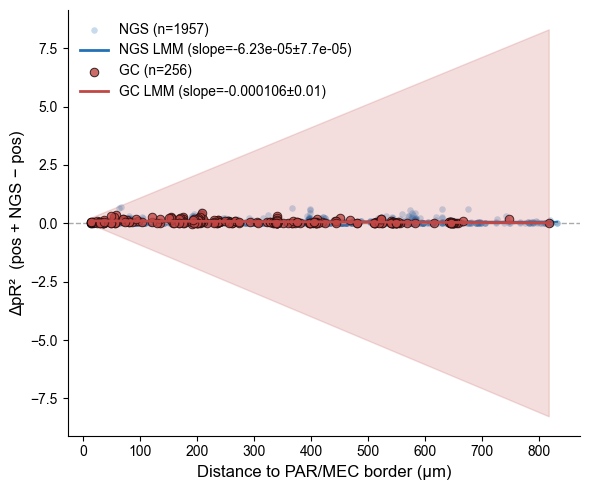

In [19]:
# ── ΔpR² vs distance to PAR/MEC border using StereoToCCF (ENT target cells) ──
#
# This version fits a linear mixed model (LMM) with random intercepts for mouse, day, and cluster_id.
# The fixed effect of interest is the slope of distance to PAR/MEC border.
# The code overlays grid cells (GC) on top of NGS cells, and plots the LMM fit ± 1 SE.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
import statsmodels.formula.api as smf

# ── 1. Locate PAR voxels in the CCF atlas ─────────────────────────────────────
_par_ids = structure_set[
    structure_set['acronym'].str.match(r'^PAR', na=False)
]['id'].values
print(f"PAR structure IDs: {_par_ids}  "
      f"({list(structure_set.loc[structure_set['id'].isin(_par_ids), 'acronym'])})")

_par_mask = np.isin(annotations_set, _par_ids)
_par_voxels = np.argwhere(_par_mask)
print(f"PAR voxels in atlas: {len(_par_voxels)}")

if len(_par_voxels) == 0:
    raise RuntimeError("No PAR voxels found — check structure_set acronyms.")

_par_tree = cKDTree(_par_voxels)

# ── 2. ΔpR² per cell (same-shank pos+ngs_shank minus pos) ────────────────────
_bl = results_df[
    results_df['covariate_type'] == 'pos'
][['mouse', 'day', 'target_cluster_id', 'target_shank_id', 'target_cell_type', 'pR2_cv']].copy()

_ngs_sh = results_df[
    (results_df['covariate_type'] == 'pos+ngs_shank') &
    (results_df['cov_shank_id'] == results_df['target_shank_id'])
][['mouse', 'day', 'target_cluster_id', 'target_shank_id', 'pR2_cv']].copy()

_delta = pd.merge(
    _bl, _ngs_sh,
    on=['mouse', 'day', 'target_cluster_id', 'target_shank_id'],
    suffixes=('_pos', '_ngs')
)
_delta['delta_pR2'] = _delta['pR2_cv_ngs'] - _delta['pR2_cv_pos']

# ── 3. Attach SC coordinates; keep only ENT target cells ──────────────────────
_cc = cell_classifications[['mouse', 'day', 'cluster_id', 'brain_region',
                             'SC_x', 'SC_y', 'SC_z']].copy()
for _col in ['SC_x', 'SC_y', 'SC_z']:
    _cc[_col] = pd.to_numeric(_cc[_col], errors='coerce')

_delta_ent = _delta.merge(
    _cc.rename(columns={'cluster_id': 'target_cluster_id'}),
    on=['mouse', 'day', 'target_cluster_id'],
    how='inner'
)
_delta_ent = _delta_ent[
    _delta_ent['brain_region'].str.contains('ENT', na=False)
].dropna(subset=['SC_x', 'SC_y', 'SC_z']).copy()
print(f"\nENT cells to process: {len(_delta_ent)}")

# ── 4. Convert SC → CCF pixel coords and look up min distance to PAR ──────────
_dists_um = []
for _, _row in _delta_ent.iterrows():
    _brain_coord_SC = np.array([_row['SC_z'], _row['SC_y'], -_row['SC_x']])
    _brain_coord_CCF = StereoToCCF(_brain_coord_SC)
    _ccf_pixel = np.round(_brain_coord_CCF / 10).astype(int)
    _dist_px, _ = _par_tree.query(_ccf_pixel)
    _dists_um.append(float(_dist_px) * 10.0)

_delta_ent = _delta_ent.copy()
_delta_ent['dist_to_par_um'] = _dists_um

# ── 5. Fit LMM for NGS and GC separately ─────────────────────────────────────
def fit_lmm(df, label):
    if len(df) < 5:
        print(f"Not enough {label} cells for LMM.")
        return None, None, None
    # Mouse, day, and cluster_id as random effects
    df = df.copy()
    df['mouse'] = df['mouse'].astype(str)
    df['day'] = df['day'].astype(str)
    df['target_cluster_id'] = df['target_cluster_id'].astype(str)
    model = smf.mixedlm(
        "delta_pR2 ~ dist_to_par_um",
        df,
        groups=df["mouse"],
        re_formula="~dist_to_par_um",
        vc_formula={
            "day": "0 + C(day)",
            "cluster": "0 + C(target_cluster_id)"
        }
    )
    result = model.fit(reml=False)
    slope = result.params['dist_to_par_um']
    se = result.bse['dist_to_par_um']
    print(f"{label} LMM: slope={slope:.4f} ± {se:.4f} (p={result.pvalues['dist_to_par_um']:.3g})")
    return slope, se, result

is_gc = _delta_ent['target_cell_type'] == 'GC'
is_ngs = _delta_ent['target_cell_type'] == 'NG'

n_gc = is_gc.sum()
n_ngs = is_ngs.sum()
print(f"GC n={n_gc}, NGS n={n_ngs}")

# Fit LMMs
slope_ngs, se_ngs, res_ngs = fit_lmm(_delta_ent[is_ngs], "NGS")
slope_gc, se_gc, res_gc = fit_lmm(_delta_ent[is_gc], "GC")

# ── 6. Plot: NGS as background, GC overlay, LMM fits ±1SE ────────────────────
fig, ax = plt.subplots(figsize=(6, 5))

# NGS: background points and LMM fit
_ngs = _delta_ent[is_ngs]
ax.scatter(_ngs['dist_to_par_um'], _ngs['delta_pR2'],
           alpha=0.25, s=22, color=ngs_color, label=f'NGS (n={n_ngs})', zorder=1, linewidths=0)
if slope_ngs is not None:
    _xr = np.linspace(_ngs['dist_to_par_um'].min(), _ngs['dist_to_par_um'].max(), 300)
    yfit = res_ngs.params['Intercept'] + slope_ngs * _xr
    yerr = se_ngs * _xr
    ax.plot(_xr, yfit, color=ngs_color, lw=2, zorder=2, label=f'NGS LMM (slope={slope_ngs:.3g}±{se_ngs:.2g})')
    ax.fill_between(_xr, yfit - yerr, yfit + yerr, color=ngs_color, alpha=0.15, zorder=1)

# GC: overlay points and LMM fit
_gc = _delta_ent[is_gc]
ax.scatter(_gc['dist_to_par_um'], _gc['delta_pR2'],
           alpha=0.8, s=38, color=gc_color, label=f'GC (n={n_gc})', zorder=3, edgecolor='k', linewidths=0.7)
if slope_gc is not None:
    _xr_gc = np.linspace(_gc['dist_to_par_um'].min(), _gc['dist_to_par_um'].max(), 300)
    yfit_gc = res_gc.params['Intercept'] + slope_gc * _xr_gc
    yerr_gc = se_gc * _xr_gc
    ax.plot(_xr_gc, yfit_gc, color=gc_color, lw=2, zorder=4, label=f'GC LMM (slope={slope_gc:.3g}±{se_gc:.2g})')
    ax.fill_between(_xr_gc, yfit_gc - yerr_gc, yfit_gc + yerr_gc, color=gc_color, alpha=0.18, zorder=3)

ax.axhline(0, color='#aaa', lw=1, ls='--')
ax.set_xlabel('Distance to PAR/MEC border (µm)', fontsize=12)
ax.set_ylabel('ΔpR²  (pos + NGS − pos)', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(frameon=False, fontsize=10)
plt.tight_layout()
plt.show()

PAR structure IDs: [843 852]  (['PAR', 'PARN'])
PAR voxels in atlas: 3163490

ENT cells to process: 2213
GC n=256, NGS n=1957


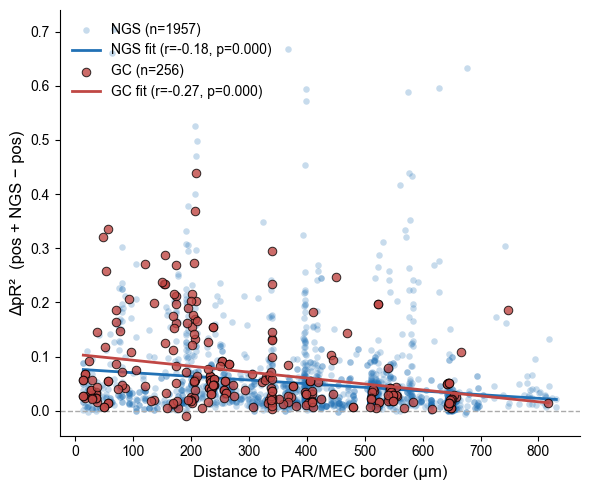

In [20]:
# ── ΔpR² vs distance to PAR/MEC border using StereoToCCF (ENT target cells) ──
#
# Method:
#   1. Find all PAR (parasubiculum) voxels in the Allen CCF atlas (annotations_set,
#      10 µm/voxel) using PAR acronym IDs from structure_set.
#   2. Build a cKDTree over those voxel coordinates.
#   3. For each ENT target cell, convert its stereotaxic coords (SC_z, SC_y, SC_x)
#      to CCF pixel indices via StereoToCCF, then query the tree for nearest PAR
#      voxel — distance × 10 = µm.
#
# SC coordinate convention (from SUPP_CELL_LOCATION notebook):
#   brain_coord_SC = [AP, DV, ML]  =  [SC_z,  SC_y,  -SC_x]
#   (SC_x is negative for lateral, so ML = -SC_x gives a positive lateral value)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from scipy import stats

# ── 1. Locate PAR voxels in the CCF atlas ─────────────────────────────────────
_par_ids = structure_set[
    structure_set['acronym'].str.match(r'^PAR', na=False)
]['id'].values
print(f"PAR structure IDs: {_par_ids}  "
      f"({list(structure_set.loc[structure_set['id'].isin(_par_ids), 'acronym'])})")

_par_mask = np.isin(annotations_set, _par_ids)
_par_voxels = np.argwhere(_par_mask)
print(f"PAR voxels in atlas: {len(_par_voxels)}")

if len(_par_voxels) == 0:
    raise RuntimeError("No PAR voxels found — check structure_set acronyms.")

_par_tree = cKDTree(_par_voxels)

# ── 2. ΔpR² per cell (same-shank pos+ngs_shank minus pos) ────────────────────
_bl = results_df[
    results_df['covariate_type'] == 'pos'
][['mouse', 'day', 'target_cluster_id', 'target_shank_id', 'target_cell_type', 'pR2_cv']].copy()

_ngs_sh = results_df[
    (results_df['covariate_type'] == 'pos+ngs_shank') &
    (results_df['cov_shank_id'] == results_df['target_shank_id'])
][['mouse', 'day', 'target_cluster_id', 'target_shank_id', 'pR2_cv']].copy()

_delta = pd.merge(
    _bl, _ngs_sh,
    on=['mouse', 'day', 'target_cluster_id', 'target_shank_id'],
    suffixes=('_pos', '_ngs')
)
_delta['delta_pR2'] = _delta['pR2_cv_ngs'] - _delta['pR2_cv_pos']

# ── 3. Attach SC coordinates; keep only ENT target cells ──────────────────────
_cc = cell_classifications[['mouse', 'day', 'cluster_id', 'brain_region',
                             'SC_x', 'SC_y', 'SC_z']].copy()
for _col in ['SC_x', 'SC_y', 'SC_z']:
    _cc[_col] = pd.to_numeric(_cc[_col], errors='coerce')

_delta_ent = _delta.merge(
    _cc.rename(columns={'cluster_id': 'target_cluster_id'}),
    on=['mouse', 'day', 'target_cluster_id'],
    how='inner'
)
_delta_ent = _delta_ent[
    _delta_ent['brain_region'].str.contains('ENT', na=False)
].dropna(subset=['SC_x', 'SC_y', 'SC_z']).copy()
print(f"\nENT cells to process: {len(_delta_ent)}")

# ── 4. Convert SC → CCF pixel coords and look up min distance to PAR ──────────
_dists_um = []
for _, _row in _delta_ent.iterrows():
    _brain_coord_SC = np.array([_row['SC_z'], _row['SC_y'], -_row['SC_x']])
    _brain_coord_CCF = StereoToCCF(_brain_coord_SC)
    _ccf_pixel = np.round(_brain_coord_CCF / 10).astype(int)
    _dist_px, _ = _par_tree.query(_ccf_pixel)
    _dists_um.append(float(_dist_px) * 10.0)

_delta_ent = _delta_ent.copy()
_delta_ent['dist_to_par_um'] = _dists_um

# ── 5. Split by cell type and fit regressions ────────────────────────────────
is_gc = _delta_ent['target_cell_type'] == 'GC'
is_ngs = _delta_ent['target_cell_type'] == 'NG'

n_gc = is_gc.sum()
n_ngs = is_ngs.sum()
print(f"GC n={n_gc}, NGS n={n_ngs}")

# Regression for NGS (background)
_ngs = _delta_ent[is_ngs]
_slope_ngs, _intercept_ngs, _r_ngs, _p_ngs, _ = stats.linregress(
    _ngs['dist_to_par_um'], _ngs['delta_pR2']
) if len(_ngs) > 1 else (np.nan, np.nan, np.nan, np.nan, np.nan)

# Regression for GC (overlay)
_gc = _delta_ent[is_gc]
_slope_gc, _intercept_gc, _r_gc, _p_gc, _ = stats.linregress(
    _gc['dist_to_par_um'], _gc['delta_pR2']
) if len(_gc) > 1 else (np.nan, np.nan, np.nan, np.nan, np.nan)

# ── 6. Plot: NGS as background, GC overlay ───────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))

# NGS: background points and regression
ax.scatter(_ngs['dist_to_par_um'], _ngs['delta_pR2'],
           alpha=0.25, s=22, color=ngs_color, label=f'NGS (n={n_ngs})', zorder=1, linewidths=0)
if len(_ngs) > 1:
    _xr = np.linspace(_ngs['dist_to_par_um'].min(), _ngs['dist_to_par_um'].max(), 300)
    ax.plot(_xr, _intercept_ngs + _slope_ngs * _xr, color=ngs_color, lw=2, zorder=2, label=f'NGS fit (r={_r_ngs:.2f}, p={_p_ngs:.3f})')

# GC: overlay points and regression
ax.scatter(_gc['dist_to_par_um'], _gc['delta_pR2'],
           alpha=0.8, s=38, color=gc_color, label=f'GC (n={n_gc})', zorder=3, edgecolor='k', linewidths=0.7)
if len(_gc) > 1:
    _xr_gc = np.linspace(_gc['dist_to_par_um'].min(), _gc['dist_to_par_um'].max(), 300)
    ax.plot(_xr_gc, _intercept_gc + _slope_gc * _xr_gc, color=gc_color, lw=2, zorder=4, label=f'GC fit (r={_r_gc:.2f}, p={_p_gc:.3f})')

ax.axhline(0, color='#aaa', lw=1, ls='--')
ax.set_xlabel('Distance to PAR/MEC border (µm)', fontsize=12)
ax.set_ylabel('ΔpR²  (pos + NGS − pos)', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(frameon=False, fontsize=10)
plt.tight_layout()
plt.show()

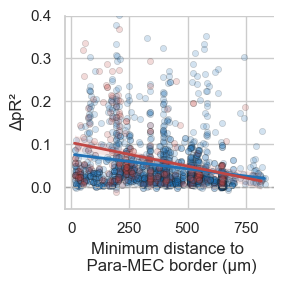

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare a DataFrame for plotting
plot_df = _delta_ent[is_gc | is_ngs].copy()
plot_df['cell_type'] = np.where(plot_df['target_cell_type'] == 'GC', 'GC', 'NGS')

# Create a 3x3 inch figure and axis
fig, ax = plt.subplots(figsize=(3, 3))

# Plot with seaborn's regplot for each cell type
for cell_type, color in zip(['NGS', 'GC'], [ngs_color, gc_color]):
    sub = plot_df[plot_df['cell_type'] == cell_type]
    sns.regplot(
        data=sub,
        x='dist_to_par_um',
        y='delta_pR2',
        scatter=True,
        scatter_kws={'alpha': 0.2, 's': 20, 'edgecolor': 'k', 'linewidths': 0.5},
        line_kws={'lw': 2},
        color=color,
        ax=ax,
        label=cell_type,
        ci=95
    )

ax.axhline(0, color='#aaa', lw=1, ls='--')
ax.set_xlabel(f'Minimum distance to \n Para-MEC border (µm)')
ax.set_ylabel('ΔpR²')
ax.set_ylim(-0.05, 0.4)
sns.despine()
plt.tight_layout()
plt.show()

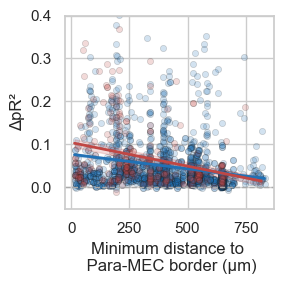

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Prepare a DataFrame for plotting
plot_df = _delta_ent[is_gc | is_ngs].copy()
plot_df['cell_type'] = np.where(plot_df['target_cell_type'] == 'GC', 'GC', 'NGS')

fig, ax = plt.subplots(figsize=(3, 3))

for cell_type, color in zip(['NGS', 'GC'], [ngs_color, gc_color]):
    sub = plot_df[plot_df['cell_type'] == cell_type]
    # Scatter
    ax.scatter(
        sub['dist_to_par_um'], sub['delta_pR2'],
        alpha=0.2, s=20, edgecolor='k', linewidths=0.5, color=color, label=f'{cell_type} points'
    )
    # Regression line and 95% CI
    if len(sub) > 1:
        x = sub['dist_to_par_um'].values
        y = sub['delta_pR2'].values
        # Sort for plotting
        idx = np.argsort(x)
        x_sorted = x[idx]
        y_sorted = y[idx]
        # Fit regression
        slope, intercept, r, p, stderr = stats.linregress(x, y)
        y_pred = intercept + slope * x_sorted
        # 95% CI
        n = len(x)
        y_err = stats.sem(y)
        ci = 1.96 * y_err
        ax.plot(x_sorted, y_pred, color=color, lw=2, label=f'{cell_type} fit')
        ax.fill_between(x_sorted, y_pred - ci, y_pred + ci, color=color, alpha=0.18)

ax.axhline(0, color='#aaa', lw=1, ls='--')
ax.set_xlabel('Minimum distance to \n Para-MEC border (µm)')
ax.set_ylabel('ΔpR²')
ax.set_ylim(-0.05, 0.4)
plt.tight_layout()
plt.show()

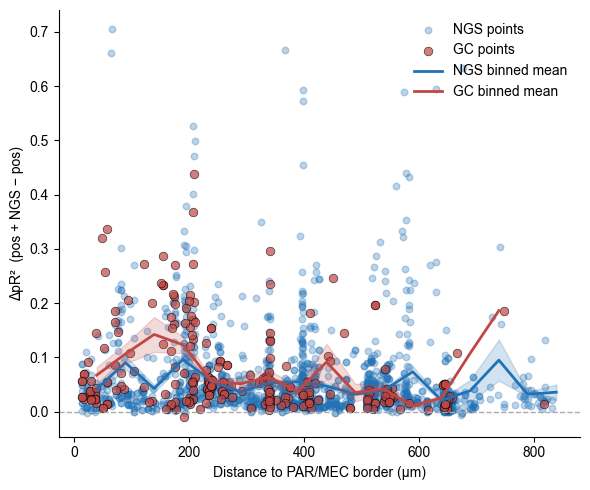

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# Define bin edges (200 µm increments)
all_dists = np.concatenate([_gc['dist_to_par_um'].values, _ngs['dist_to_par_um'].values])
bin_edges = np.arange(np.nanmin(all_dists), np.nanmax(all_dists) + 50, 50)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

def binned_stats(df, value_col, bin_col, bin_edges):
    means = []
    sems = []
    for i in range(len(bin_edges) - 1):
        mask = (df[bin_col] >= bin_edges[i]) & (df[bin_col] < bin_edges[i+1])
        vals = df.loc[mask, value_col]
        if len(vals) > 0:
            means.append(vals.mean())
            sems.append(vals.sem())
        else:
            means.append(np.nan)
            sems.append(np.nan)
    return np.array(means), np.array(sems)

gc_means, gc_sems = binned_stats(_gc, 'delta_pR2', 'dist_to_par_um', bin_edges)
ngs_means, ngs_sems = binned_stats(_ngs, 'delta_pR2', 'dist_to_par_um', bin_edges)

fig, ax = plt.subplots(figsize=(6, 5))

# Scatter all points
ax.scatter(_ngs['dist_to_par_um'], _ngs['delta_pR2'], color=ngs_color, alpha=0.3, s=22, label='NGS points', zorder=1)
ax.scatter(_gc['dist_to_par_um'], _gc['delta_pR2'], color=gc_color, alpha=0.7, s=38, label='GC points', zorder=2, edgecolor='k', linewidths=0.5)

# Plot binned means
ax.plot(bin_centers, ngs_means, color=ngs_color, lw=2, label='NGS binned mean', zorder=3)
ax.plot(bin_centers, gc_means, color=gc_color, lw=2, label='GC binned mean', zorder=4)

# Fill between for SEM
ax.fill_between(bin_centers, ngs_means-ngs_sems, ngs_means+ngs_sems, color=ngs_color, alpha=0.2, zorder=2)
ax.fill_between(bin_centers, gc_means-gc_sems, gc_means+gc_sems, color=gc_color, alpha=0.2, zorder=3)

ax.set_xlabel('Distance to PAR/MEC border (µm)')
ax.set_ylabel('ΔpR²  (pos + NGS − pos)')
ax.axhline(0, color='#aaa', lw=1, ls='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(frameon=False, fontsize=10)
plt.tight_layout()
plt.show()